In [2]:
import pandas as pd 

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1') 
print(df.shape)
print(df.columns.tolist())


(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
import warnings
warnings.filterwarnings('ignore')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month-Year'] = df['Order Date'].dt.to_period('M')

print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Total unique orders:", df['Order ID'].nunique())
print("Total sales: $", round(df['Sales'].sum(), 2))
print("Total profit: $", round(df['Profit'].sum(), 2))

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total unique orders: 5009
Total sales: $ 2297200.86
Total profit: $ 286397.02


Matplotlib is building the font cache; this may take a moment.


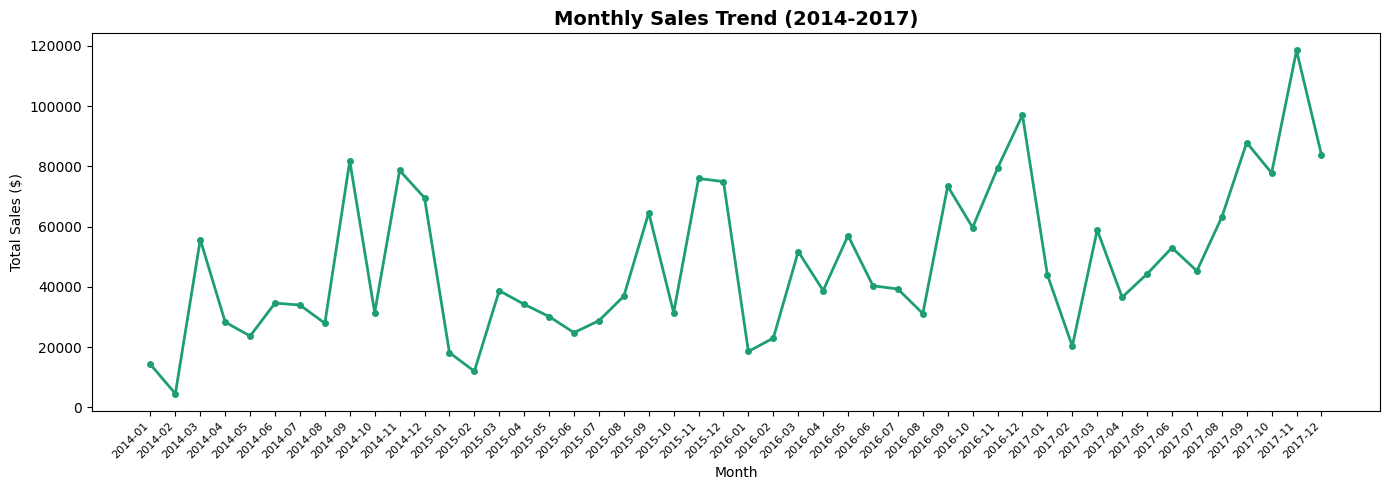

In [4]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'],
         color='#1D9E75', linewidth=2, marker='o', markersize=4)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()

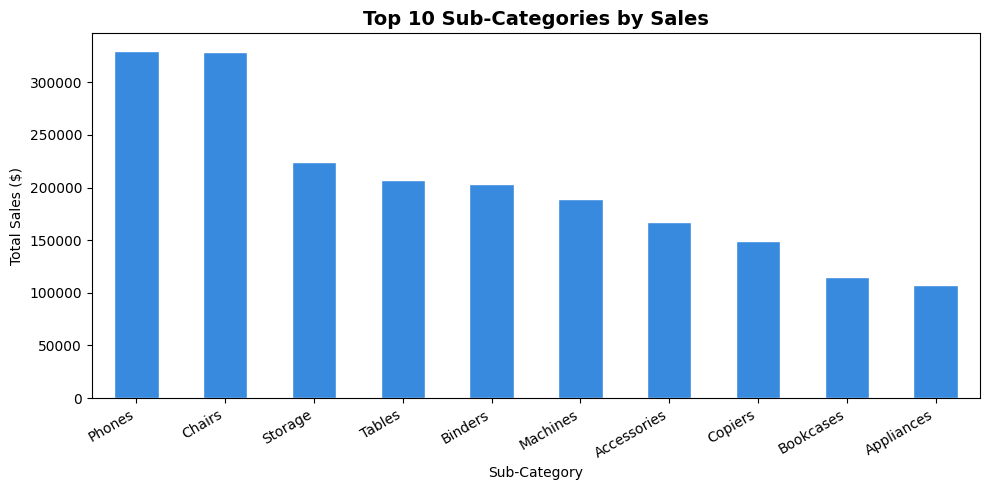

In [5]:
top_subcats = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_subcats.plot(kind='bar', color='#378ADD', edgecolor='white')
plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('top_subcategories.png', dpi=150)
plt.show()

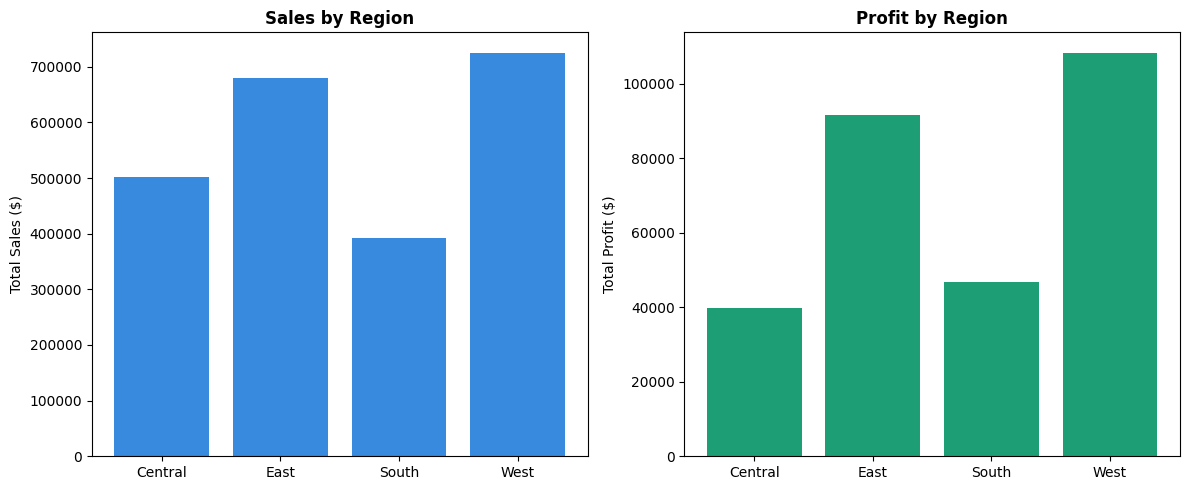

In [7]:
region_sales = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(region_sales['Region'], region_sales['Sales'], color='#378ADD')
axes[0].set_title('Sales by Region', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')

axes[1].bar(region_sales['Region'], region_sales['Profit'],
            color=['#1D9E75' if x > 0 else '#E24B4A' for x in region_sales['Profit']])
axes[1].set_title('Profit by Region', fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('region_performance.png', dpi=150)
plt.show()

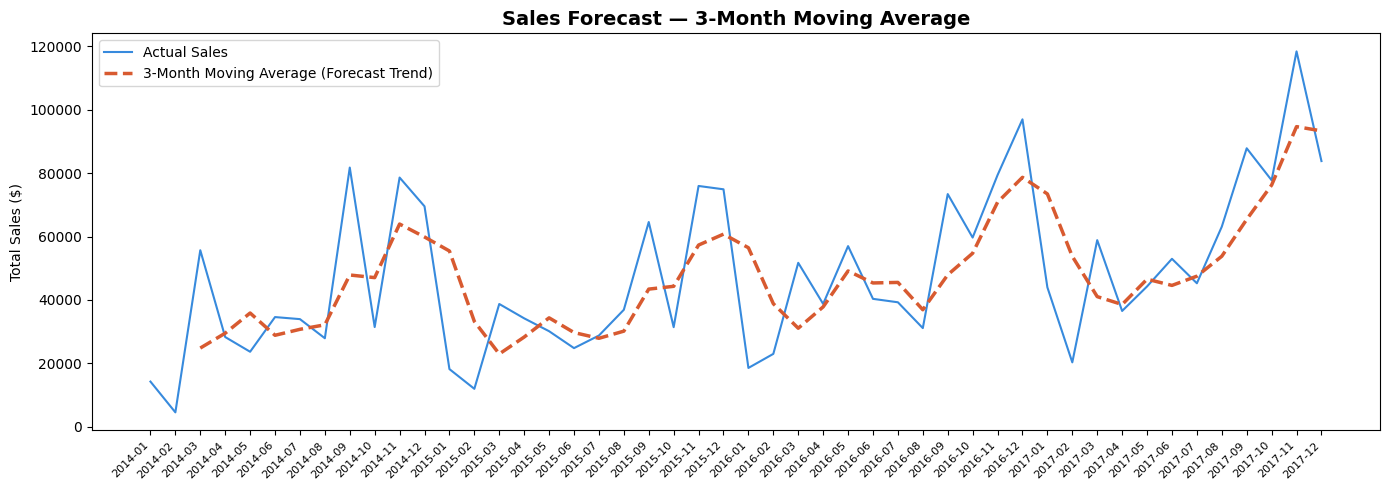

In [8]:
monthly_sales['Sales_MA3'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'],
         label='Actual Sales', color='#378ADD', linewidth=1.5)
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales_MA3'],
         label='3-Month Moving Average (Forecast Trend)', 
         color='#D85A30', linewidth=2.5, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Sales Forecast — 3-Month Moving Average', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150)
plt.show()